In [6]:
%%bash

## Data Preparation

# unzip single cell FASTQ files, ref genome (chr5), and GTF file w/ transcript info
tar -xzf toy_read_ref_set.tar.gz

# unzip the whitelist barcodes and put stdout into text file
gunzip -kf 3M-february-2018.txt.gz > 3M-february-2018.txt

Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


In [7]:
%%bash

fastq_dir="toy_ref_read/toy_read_fastq"
ref_dir="toy_ref_read/toy_human_ref"

## Building the index

# make splici reference
## Usage: pyroe make-splici genome_file gtf_file read_length out_dir
## The read_lengh is the number of sequencing cycles performed by the sequencer. Ask your technician if you are not sure about it.
## Publicly available datasets usually have the read length in the description.
pyroe make-splici \
${ref_dir}/fasta/genome.fa \
${ref_dir}/genes/genes.gtf \
90 \
splici_rl90_ref

# Index the reference
## Usage: salmon index -t extend_txome.fa -i idx_out_dir -p num_threads
## The $() expression runs the command inside and puts the output in place.
## Please ensure that only one file ends with ".fa" in the `splici_ref` folder.
salmon index \
-t $(ls splici_rl90_ref/*\.fa) \
-i salmon_index \
-p 8

Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
/Users/michellerosenthal/miniconda3/envs/af3/lib/python3.11/site-packages/pyranges/__init__.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Version Server Response: Not Found
[2025-11-22 12:25:17.538] [jLog] [warning] The salmon index is being built without any decoy sequences.  It is recommended that decoy sequence (either computed auxiliary decoy sequence or the genome of the organism) be provided during indexing. Further details can be found at https://salmon.readthedocs.io/en/latest/salmon.html#preparing-transcriptome-indices-mapping-based-mode.
[2025-11-22 12:25:17.539] [jLog] [info] building index
out : salmon_index
[2025-11-22 12:25:17.539] [puff:

Threads = 8
Vertex length = 31
Hash functions = 5
Filter size = 67108864
Capacity = 2
Files: 
salmon_index/ref_k31_fixed.fa
--------------------------------------------------------------------------------
Round 0, 0:67108864
Pass	Filling	Filtering
1	0	0	
2	0	0
True junctions count = 9520
False junctions count = 10744
Hash table size = 20264
Candidate marks count = 68084
--------------------------------------------------------------------------------
Reallocating bifurcations time: 0
True marks count: 52427
Edges construction time: 0
--------------------------------------------------------------------------------
Distinct junctions = 9520



TwoPaCo::buildGraphMain:: allocated with scalable_malloc; freeing.
TwoPaCo::buildGraphMain:: Calling scalable_allocation_command(TBBMALLOC_CLEAN_ALL_BUFFERS, 0);
allowedIn: 18
Max Junction ID: 9602
seen.size():76825 kmerInfo.size():9603
approximateContigTotalLength: 1104625
counters for complex kmers:
(prec>1 & succ>1)=1549 | (succ>1 & isStart)=1 | (prec>1 & isEnd)=1 | (isStart & isEnd)=0
contig count: 15290 element count: 2453489 complex nodes: 1551
# of ones in rank vector: 15289
[2025-11-22 12:25:18.082] [puff::index::jointLog] [info] Starting the Pufferfish indexing by reading the GFA binary file.
[2025-11-22 12:25:18.082] [puff::index::jointLog] [info] Setting the index/BinaryGfa directory salmon_index
size = 2453489
-----------------------------------------
| Loading contigs | Time = 274.5 us
-----------------------------------------
size = 2453489
-----------------------------------------
| Loading contig boundaries | Time = 140.46 us
-----------------------------------------
Nu

for info, total work write each  : 2.331    total work inram from level 3 : 4.322  total work raw : 25.000 
Bitarray        10458112  bits (100.00 %)   (array + ranks )
final hash             0  bits (0.00 %) (nb in final hash 0)


In [8]:
%%bash

# Mapping and Quantification

# Collect FASTQ files
## The filenames are sorted and separated by space.
reads1="toy_ref_read/toy_read_fastq/selected_R1_reads.fastq"
reads2="toy_ref_read/toy_read_fastq/selected_R2_reads.fastq"

# Mapping
## Usage: salmon alevin -i index_dir -l library_type -1 reads1_files -2 reads2_files -p num_threads -o output_dir
## The variable reads1 and reads2 defined above are passed in using ${}.
salmon alevin \
-i salmon_index \
-l ISR \
-1 ${reads1} \
-2 ${reads2} \
-p 8 \
-o salmon_alevin \
--chromiumV3 \
--sketch

# Cell barcode correction
## Usage: alevin-fry generate-permit-list -u CB_permit_list -d expected_orientation -o gpl_out_dir
## Here, the reads that map to the reverse complement strand of transcripts are filtered out by specifying `-d fw`.
alevin-fry generate-permit-list \
-u 3M-february-2018.txt \
-d fw \
-i salmon_alevin \
-o alevin_fry_gpl

# Filter mapping information
## Usage: alevin-fry collate -i gpl_out_dir -r alevin_map_dir -t num_threads
alevin-fry collate \
-i alevin_fry_gpl \
-r salmon_alevin \
-t 8

# UMI resolution + quantification
## Usage: alevin-fry quant -r resolution -m txp_to_gene_mapping -i gpl_out_dir -o quant_out_dir -t num_threads
## The file ends with `3col.tsv` in the splici_ref folder will be passed to the -m argument.
## Please ensure that there is only one such file in the `splici_ref` folder.
alevin-fry quant -r cr-like \
-m $(ls splici_rl90_ref/*3col.tsv) \
-i alevin_fry_gpl \
-o alevin_fry_quant \
-t 8

Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Version Server Response: Not Found
[2025-11-22 12:25:18.530] [alevinLog] [info] currently, --sketch implies --rad. Running in alignment-only mode (will write a RAD output).
[2025-11-22 12:25:18.530] [alevinLog] [info] The --rad flag was passed to alevin. The reads will be selectively aligned and the output written to a RAD file.Arguments passed that correspond to other processing steps will be ignored
[2025-11-22 12:25:18.530] [alevinLog] [info] The --sketch flag was passed; the alignment will be run in sketch mode.
Logs will be written to salmon_alevin/logs
[2025-11-22 12:25:18.539] [jointLog] [info] setting maxHashResizeThreads to 8
[2025-11-22 12:25:18.539] [jointLog] [info] Fragment incompatibility prior below threshold.  Incompatible fragments will be ignored.
[2025-11-22 12:25:18.539] [jointLog] [info] The --mimicBT2, --mimicStrictBT2 and --hardFilter flags imply mapp

In [12]:
# create anndata object

import pyroe
adata = pyroe.load_fry("alevin_fry_quant", output_format={'X' : ['S']})

USA mode: True
Processing user-defined output format.
Will populate output field X with sum of counts frorm ['S'].


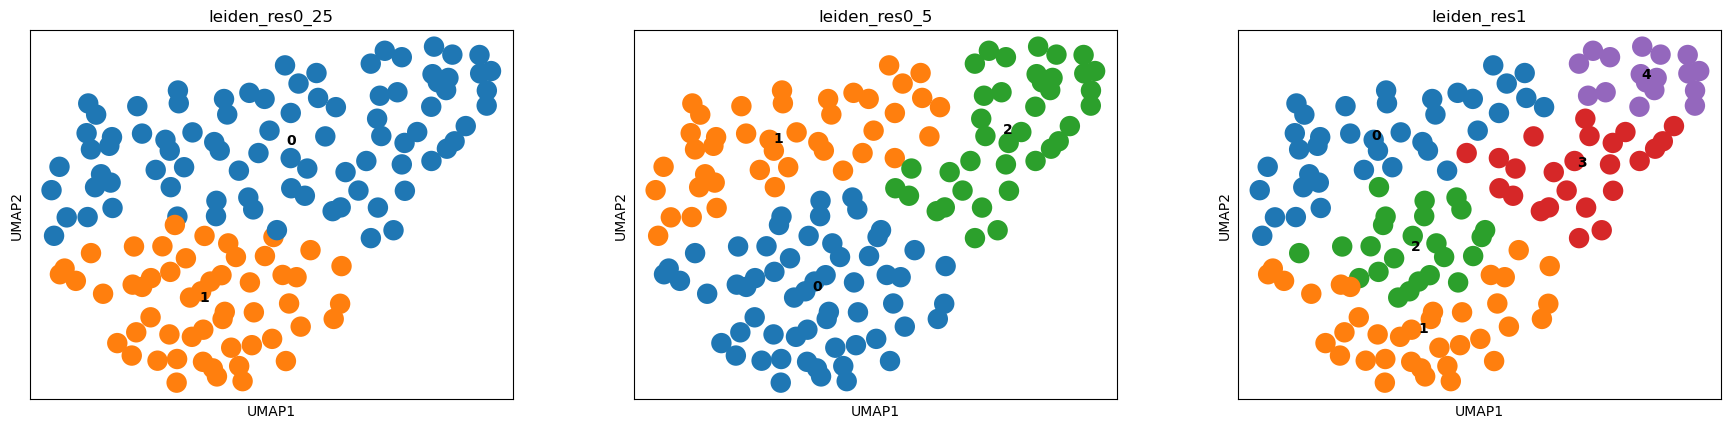

In [13]:
# clustering

import scanpy as sc
sc.pp.neighbors(adata, n_pcs=30)
sc.tl.umap(adata)

sc.tl.leiden(adata)
sc.tl.leiden(adata, key_added="leiden_res0_25", resolution=0.25)
sc.tl.leiden(adata, key_added="leiden_res0_5", resolution=0.5)
sc.tl.leiden(adata, key_added="leiden_res1", resolution=1.0)

sc.pl.umap(
    adata,
    color=["leiden_res0_25", "leiden_res0_5", "leiden_res1"],
    legend_loc="on data",
)

In [33]:
# convert gene_ids to name to work with celltypist

id_to_name = {}

gene_id_to_name = "splici_rl90_ref/gene_id_to_name.tsv"
for line in open(gene_id_to_name, "r"):
    line = line.strip()
    gene_id, gene_name = line.split()
    id_to_name[gene_id] = gene_name

curr_index = adata.var.index
new_index = [id_to_name[gene_id] for gene_id in curr_index]
adata.var["gene_symbol"] = new_index
adata.var_names = adata.var["gene_symbol"]

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 59
📂 Storing models in /Users/michellerosenthal/.celltypist/data/models
💾 Total models to download: 2
💾 Downloading model [1/2]: Immune_All_Low.pkl
💾 Downloading model [2/2]: Immune_All_High.pkl
🔬 Input data has 139 cells and 20 genes
🔗 Matching reference genes in the model
🧬 10 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!
🔬 Input data has 139 cells and 20 genes
🔗 Matching reference genes in the model
🧬 10 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data 

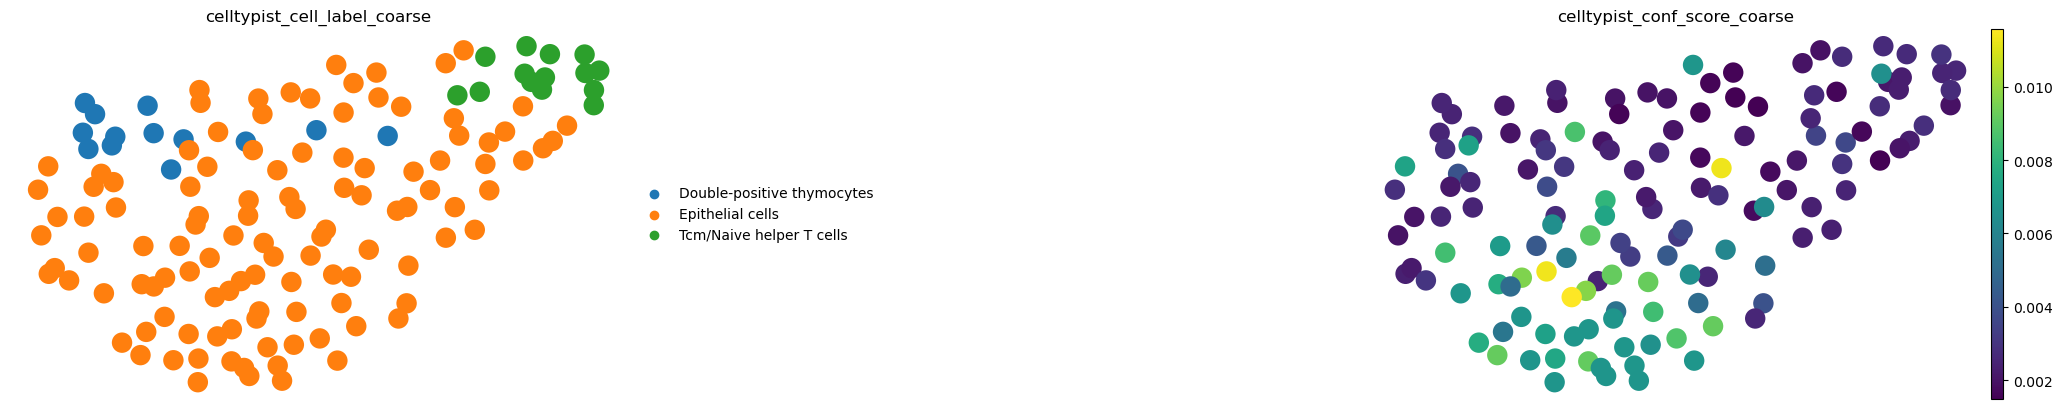

In [35]:
# automatic annotation using celltypist

import celltypist
from celltypist import models

# normalize data to 10000 counts per cell and log1p transform

adata_celltypist = adata.copy()  # make a copy of our adata
adata.layers["counts"] = adata.X
adata_celltypist.X = adata.layers["counts"]  # set adata.X to raw counts
sc.pp.normalize_total(
    adata_celltypist, target_sum=10**4
)  # normalize to 10,000 counts per cell
sc.pp.log1p(adata_celltypist)  # log-transform
# make .X dense instead of sparse, for compatibility with celltypist:
adata_celltypist.X = adata_celltypist.X.toarray()

# download celltypist models for immune cells
models.download_models(
    force_update=True, model=["Immune_All_Low.pkl", "Immune_All_High.pkl"]
)

# try out both the Immune_All_Low and Immune_All_High models (these annotate immune cell types finer annotation level (low) and coarser (high)):
model_low = models.Model.load(model="Immune_All_Low.pkl")
model_high = models.Model.load(model="Immune_All_High.pkl")

# run the models
predictions_high = celltypist.annotate(
    adata_celltypist, model=model_high, majority_voting=True
)
predictions_low = celltypist.annotate(
    adata_celltypist, model=model_low, majority_voting=True
)

# transform the predictions to anndata to get full output
predictions_high_adata = predictions_high.to_adata()
predictions_low_adata = predictions_low.to_adata()

# copy results to original adata object
adata.obs["celltypist_cell_label_coarse"] = predictions_high_adata.obs.loc[
    adata.obs.index, "majority_voting"
]
adata.obs["celltypist_conf_score_coarse"] = predictions_high_adata.obs.loc[
    adata.obs.index, "conf_score"
]
adata.obs["celltypist_cell_label_fine"] = predictions_low_adata.obs.loc[
    adata.obs.index, "majority_voting"
]
adata.obs["celltypist_conf_score_fine"] = predictions_low_adata.obs.loc[
    adata.obs.index, "conf_score"
]

# plot
sc.pl.umap(
    adata,
    color=["celltypist_cell_label_coarse", "celltypist_conf_score_coarse"],
    frameon=False,
    sort_order=False,
    wspace=1,
)

## Gotchas

pyroe installation
- pyroe was not automatically installed because my version of python (3.14) was too high
- I had to create a new environment with python3.11
- I made the mistake of pip install pyroe, which installed some libraries as ARM and others as osx-64
- Using conda install pyroe worked
- ChatGPT was helpful in getting me out of this

## Time Spent
8 hours